This script is intended to perform and register all the selection steps involved.
<br>
Here we are able to work at once Data and MC processed files with the following recipe:
- Load merged & tagged event/peak-level dataframe.
- Use HE scale and perform trigger02 efficiency cut.
- Select $nS2=1$ for fiducial events (electron-like).
- Select $ncluster=1$ for single track events.
- Update summary with event counter per run/isotope.
- Plot.

In [83]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
import pandas as pd
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Configuration

In [2]:
# --- Notebook Parameters
VERSION_TAG = "LPR_p2_v2"
ANA_OPTIONS =  ['data', 'mc']
ANA_INFO = {opt:{} for opt in ANA_OPTIONS }

In [4]:
# -------------------
# LOAD CONFIGURATIONS
# -------------------
CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Universal/configs/he_analysis_config.yaml'

try:
    with open(CONFIG_FILE, 'r') as f:
        all_configs = yaml.safe_load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file '{CONFIG_FILE}' not found. Please check the path and try again.")

if VERSION_TAG not in all_configs:
    raise ValueError(f"Version tag '{VERSION_TAG}' not found in the configuration file. Available tags: {list(all_configs.keys())}")

# Set up the configuration
common_config = all_configs['common']
ana_config    = all_configs[VERSION_TAG]

for ana_type in ANA_OPTIONS:
    if ana_type in ana_config:
        print(f"{'-'*5} Loading configuration for {ana_type.upper()}")

        # Load directories and paths
        input_dir   = common_config['input_dir']
        summary_dir = common_config['summary_dir']
        input_path   = os.path.join(input_dir,   ana_config[ana_type]['processed_file'])
        summary_path = os.path.join(summary_dir, ana_config[ana_type]['summary_file'])
        print(f"  Input file path   : {input_path}")
        print(f"  Summary file path : {summary_path}")

        # Load dataframes
        df_events  = pd.read_hdf(input_path, key=common_config['evt_key'])
        df_summary = pd.read_csv(summary_path)
        df_summary.drop(columns=['Unnamed: 0'], inplace=True)
        df_summary.columns = df_summary.columns.str.strip()

        # Store information
        ANA_INFO[ana_type] = { 'df_processed' : df_events
                             , 'df_summary'   : df_summary
                             , 'he_scale'     : ana_config[ana_type]['he_scale']
                             , 'groupers'     : ('run_number', 'Run_ID') if ana_type == 'data' else ('isotope', 'Isotope') }

        print(f"Loaded successfully.\n")

# ----------------
# GLOBAL CONSTANTS
# ----------------
# Trigger 2 efficiency cut
TRG2_THRESHOLD = 0.5        # in [MeV]

# Geometric boundaries for fiducial volume
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

----- Loading configuration for DATA
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Th_analysis/h5/merged_tagged_runs_LPR_p2_v2.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/txt/summaries/summary_LPR_p2_v2_processed.csv
Loaded successfully.

----- Loading configuration for MC
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Th_analysis/h5/merged_tagged_mc_calibration_lpr.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/txt/summaries/summary_calibration_lpr_processed.csv
Loaded successfully.



# Reconstructed

In [5]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_processed']
    df_summ = ANA_INFO[ana_type]['df_summary']
    m_he_scale = ANA_INFO[ana_type]['he_scale']['m']
    b_he_scale = ANA_INFO[ana_type]['he_scale']['b']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- Electron-like Cut --- #
    if ana_type == 'data':
        df_temp = df_temp[df_temp['particle'] == 'electron'].copy()
    elif ana_type == 'mc':  
        pass    # In MC there are only electrons

    # --- HE Scale --- #
    df_temp = crudo.ef.he_scale_converter(df_temp, m_he_scale, b_he_scale, input_column='E_evt', output_column='E_final')
    df_temp = df_temp[df_temp['E_final'] >= TRG2_THRESHOLD].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Reconstructed'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_reco']    = df_temp
    ANA_INFO[ana_type]['df_summary'] = df_summ

# Selection

In [4]:
# for ana_type in ANA_OPTIONS:

#     df_temp = ANA_INFO[ana_type]['df_processed']
#     df_summ = ANA_INFO[ana_type]['df_summary']
#     m_he_scale = ANA_INFO[ana_type]['he_scale']['m']
#     b_he_scale = ANA_INFO[ana_type]['he_scale']['b']
#     col_df, col_summ = ANA_INFO[ana_type]['groupers']

#     # --- HE Scale & Cut --- #
#     df_temp = crudo.ef.he_scale_converter(df_temp, m_he_scale, b_he_scale, input_column='E_evt_mev', output_column='E_final')
#     df_temp = df_temp[df_temp['E_final'] >= TRG2_THRESHOLD].copy()

#     # --- Update --- #
#     cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
#     df_summ['Trg2_Cut'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
#     ANA_INFO[ana_type]['df_processed'] = df_temp
#     ANA_INFO[ana_type]['df_summary']   = df_summ

## Inclusive Electrons

### $nS2=1$

In [6]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_reco']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- nS2 = 1 Cut --- #
    df_temp = df_temp[df_temp['nS2'] == 1].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Inclusive'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_inclusive'] = df_temp
    ANA_INFO[ana_type]['df_summary']   = df_summ

## Fiducial Electrons

In [7]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_inclusive']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- Fiducial Volume Cut --- #
    df_temp = df_temp[df_temp['region'] == 'fiducial'].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Fiducial'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_fiducial'] = df_temp
    ANA_INFO[ana_type]['df_summary']  = df_summ

## Single Track: or cluster ;)

In [8]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_fiducial']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- Single Track Cut --- #
    df_temp = df_temp[df_temp['n_cluster'] == 1].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Single_Track'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_strack']  = df_temp
    ANA_INFO[ana_type]['df_summary'] = df_summ

# Update Summary

In [8]:
ana_config

{'data': {'processed_file': 'merged_tagged_runs_LPR_p2_v2.h5',
  'summary_file': 'summary_LPR_p2_v2_processed.csv',
  'he_scale': {'m': 0.952908, 'b': 0.008638}},
 'mc': {'processed_file': 'merged_tagged_mc_calibration_lpr.h5',
  'summary_file': 'summary_calibration_lpr_processed.csv',
  'he_scale': {'m': 0.997849, 'b': -0.000564}}}

In [9]:
for ana_type in ANA_OPTIONS:

    df_summ = ANA_INFO[ana_type]['df_summary']
    summ_filename = ana_config[ana_type]['summary_file']
    summ_filename = summ_filename.replace('processed', 'updated')

    df_summ.to_csv(os.path.join(common_config['summary_dir'], summ_filename))
    print('Done! Summary updated in:', summ_filename)

Done! Summary updated in: summary_LPR_p2_v2_updated.csv
Done! Summary updated in: summary_calibration_lpr_updated.csv


# Plots

## Data

In [9]:
ANA_INFO['data'].keys()

dict_keys(['df_processed', 'df_summary', 'he_scale', 'groupers', 'df_reco', 'df_inclusive', 'df_fiducial', 'df_strack'])

### Inclusive/Fiducial

### $E$ distribution

INCLUSIVE: counts = 254997
FIDUCIAL: counts = 125942


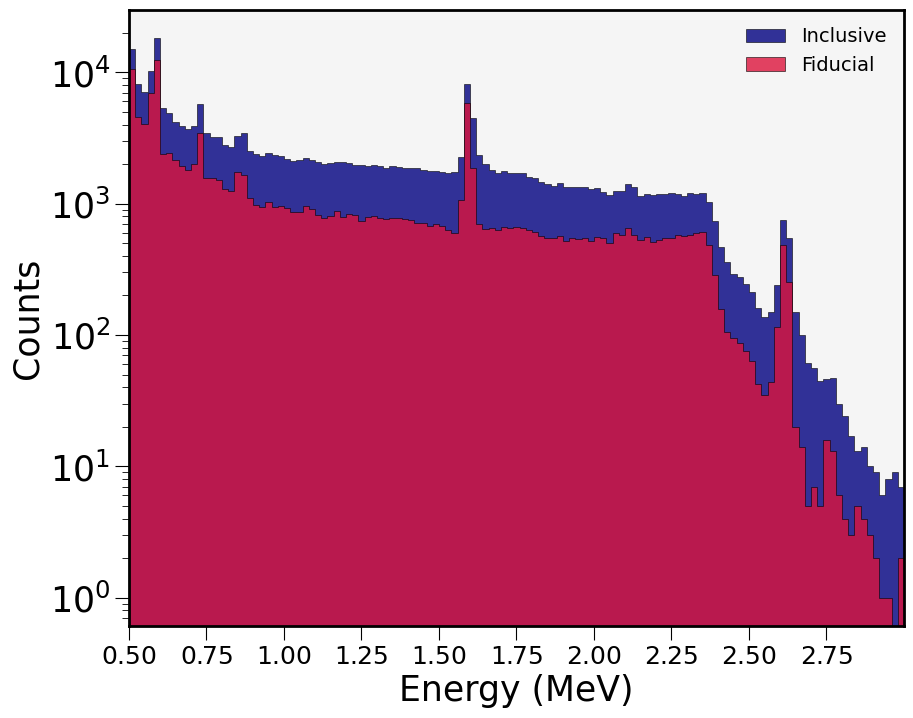

In [13]:
# Global
n_bins = 125
DEP_VALUE = 1.593       # MeV

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
plot_var = ANA_INFO['data']['df_inclusive']['E_final']
_, plot_edges = np.histogram(plot_var, bins=n_bins, range=(plot_var.min(), 3))

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    # duration = ANA_INFO['data']['duration']

    # Variable
    E_evt = dataframe['E_final']

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    # rate = counts / duration    # in [Hz]
    # print(f"{label.upper()}: counts = {counts.sum()}, corr. time = {duration:.2f} s | Rate = {rate.sum()*1e3:.4f} mHz")
    print(f"{label.upper()}: counts = {counts.sum()}")

    # ----- Plotting ----- #
    plt.stairs(counts, bin_edges, label=f'{label}', 
               fill=True, color=crudo.pt.comp_colors[i], alpha=0.8,
               ec='black', lw=0.5, zorder=i+1)

# Lines
# plt.axvline(x=DEP_VALUE, c='green', ls='--', lw=1.0, label='DEP Peak (Nominal)')

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.xticks(np.arange(0.5, 3.0, 0.25))
plt.xticks(fontsize=18)
plt.ylabel('Counts')
# plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper right', fontsize=14, facecolor='none')

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $Z$ Distribution

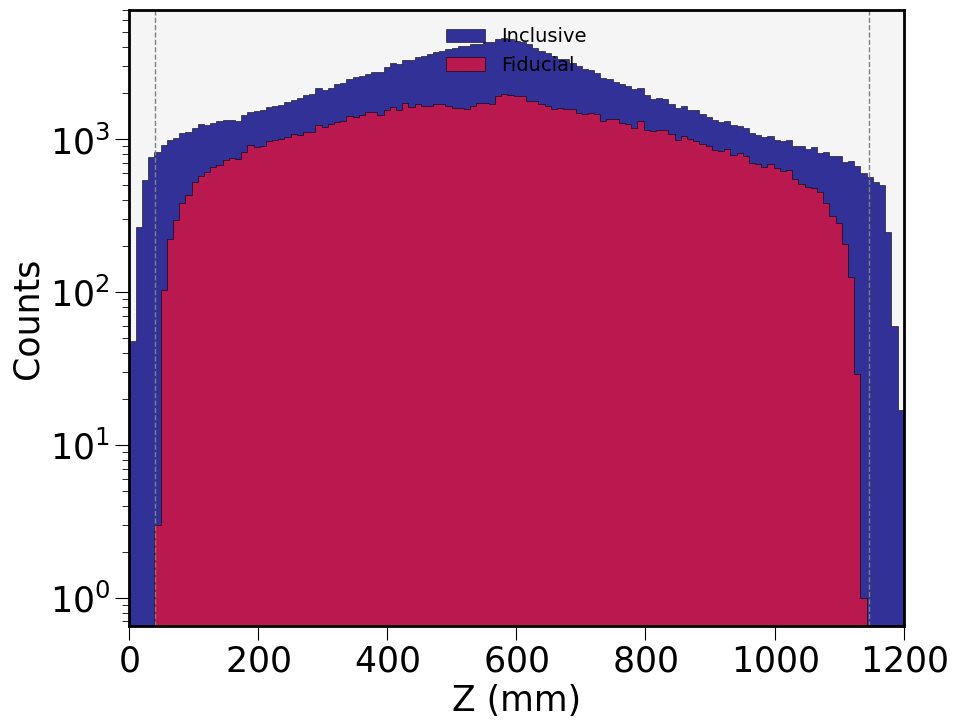

In [16]:
# Global
n_bins = 125

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
plot_var = ANA_INFO['data']['df_inclusive']['Z_bary']
_, plot_edges = np.histogram(plot_var, bins=n_bins, range=(plot_var.min(), 1200))

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    # duration = ANA_INFO['data']['duration']

    # Variable
    Z_evt = dataframe['Z_bary']

    # Histogram
    counts, bin_edges = np.histogram(Z_evt, bins=plot_edges)
    # rate = counts / duration    # in [Hz]

    # ----- Plotting ----- #
    # plt.stairs(rate, bin_edges, label=f'{label}', 
    #            fill=False, lw=1.5, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    plt.stairs(counts, bin_edges, label=f'{label}', 
               fill=True, color=crudo.pt.comp_colors[i], alpha=0.8,
               ec='black', lw=0.5, zorder=i+1)

# Lines
plt.axvline(x=Z_LOW, c='gray', ls='--', lw=1.0)
plt.axvline(x=Z_UP, c='gray', ls='--', lw=1.0)

# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Counts')
# plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper center', fontsize=14, facecolor='none')

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $R^{2}$ Distribution

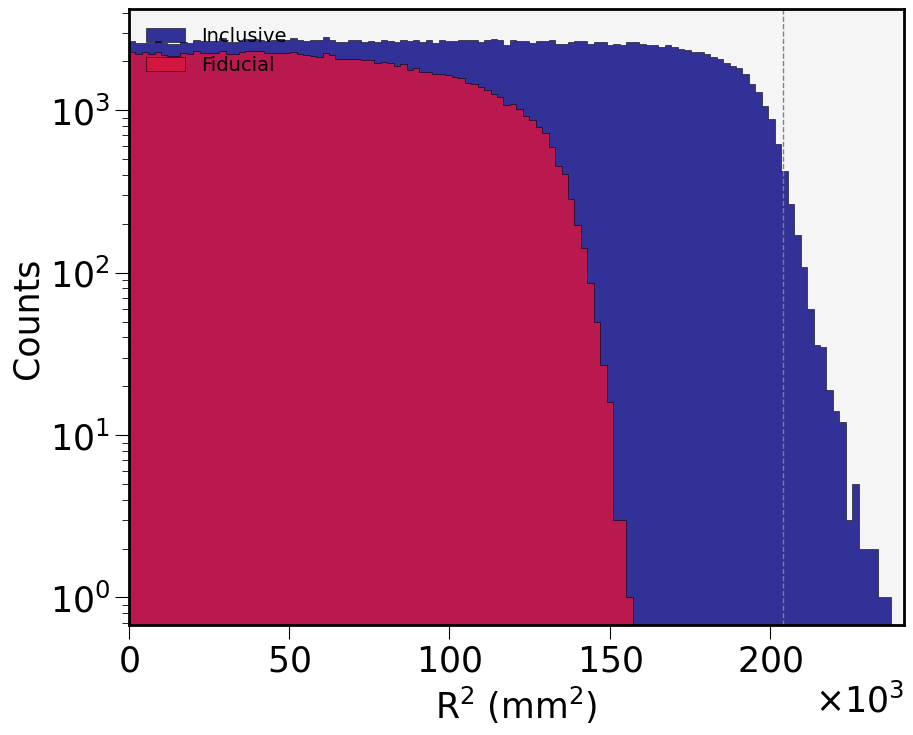

In [19]:
# Global
n_bins = 125

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
plot_var = ANA_INFO['data']['df_inclusive']['X_bary']**2 + ANA_INFO['data']['df_inclusive']['Y_bary']**2
_, plot_edges = np.histogram(plot_var, bins=n_bins)

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    # duration = ANA_INFO['data']['duration']

    # Variable
    X = dataframe['X_bary']
    Y = dataframe['Y_bary']
    R2 = X**2 + Y**2

    # Histogram
    counts, bin_edges = np.histogram(R2, bins=plot_edges)
    # rate = counts / duration    # in [Hz]

    # ----- Plotting ----- #
    # plt.stairs(rate, bin_edges, label=f'{label}', 
    #            fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    plt.stairs(counts, bin_edges, label=f'{label}', 
               fill=True, color=crudo.pt.comp_colors[i], alpha=0.8,
               ec='black', lw=0.5, zorder=i+1)

# Lines
plt.axvline(x=R_UP**2, c='gray', ls='--', lw=1.0)
plt.axvline(x=crudo.pt.N100_rad**2, c='gray', ls='--', lw=1.0)

# ----- Styling ----- #
plt.xlabel(r'R$^{2}$ (mm$^{2}$)')
plt.xlim(0, crudo.pt.N100_rad**2)
plt.ylabel('Counts')
# plt.ylim(1e-7, 1e-2)
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.yscale('log')
plt.legend(loc='upper left', fontsize=14, facecolor='none')

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/R2_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $XY$ Map

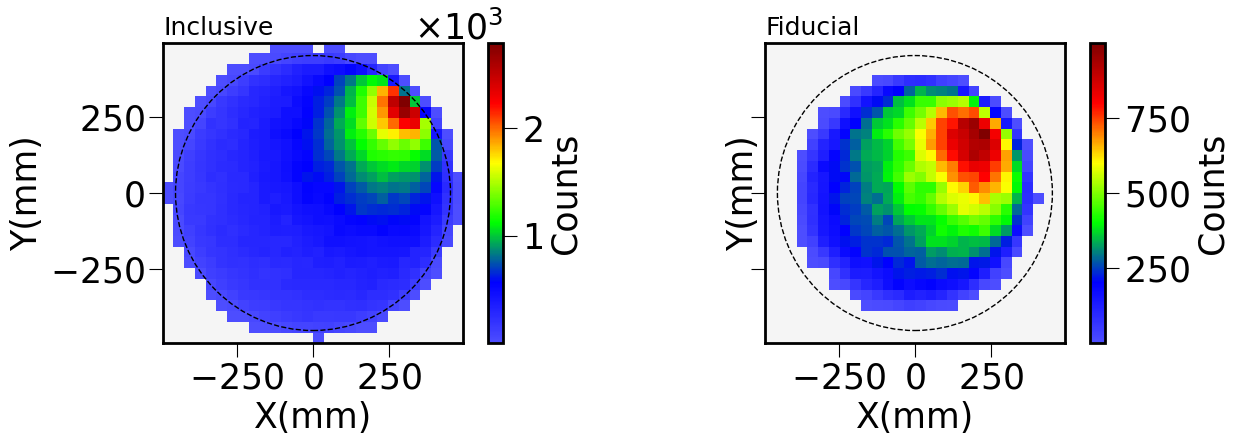

In [23]:
n_bins = 35
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    # duration = ANA_INFO['data']['duration']

    # Variables
    X = dataframe['X_bary']
    Y = dataframe['Y_bary']

    # 2D histogram: normalized by corrected DAQ data taking time
    XY_hit_map, ex, ey = crudo.pt.mapping(X, Y, xy_bins=n_bins, pos=True)
    XY_rate            = XY_hit_map # / duration      
    XY_rate            = np.ma.masked_where(XY_rate == 0, XY_rate)
    # XY_rate            = np.clip(XY_rate, 0, 4e-5)

    # ----- Plotting ----- #
    im = axes[i].pcolormesh(ex, ey, XY_rate.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(im, ax=axes[i], label='Counts', shrink=1.0)
    cbar.formatter.set_powerlimits((-3, 3))
    axes[i].set_xlabel('X(mm)')
    axes[i].set_xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_ylabel('Y(mm)')
    axes[i].set_ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].add_patch(crudo.pt.plot_circle(R_UP, linestyle='--'))   # R-lim
    axes[i].set_title(f'{label}', fontsize=18, loc='left')
    axes[i].set_facecolor("whitesmoke")


plt.tight_layout()
plt.show()

# EXTRA: Analysis on $S2$ Pulse

In [97]:
ANA_INFO['data'].keys()

dict_keys(['df_processed', 'df_summary', 'he_scale', 'groupers', 'df_reco', 'df_inclusive', 'df_fiducial', 'df_strack'])

In [32]:
PROCESS_DF = ANA_INFO['data']['df_processed']
PROCESS_DF.nS2.min()

1

DATA: Total events = 615187, Counts = 615187, Fraction = 1.00
MC: Total events = 98496, Counts = 98496, Fraction = 1.00


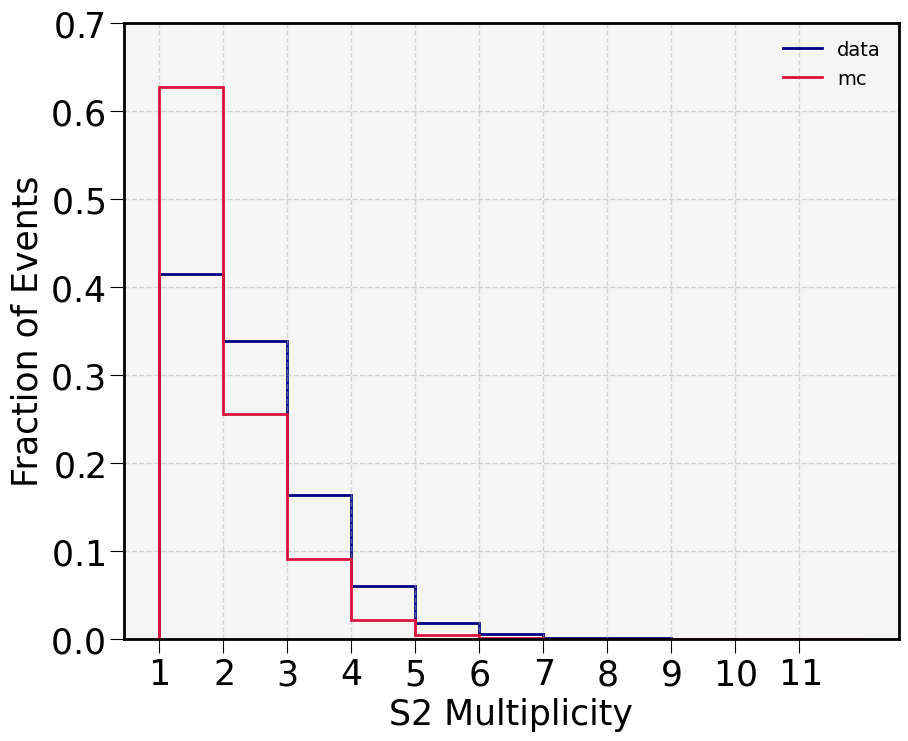

In [103]:
# Define binning
plot_var = ANA_INFO['data']['df_reco']['nS2']
plot_edges = np.arange(plot_var.min(), plot_var.max() + 2, 1)  # Bins for integer values

for i, ana_type in enumerate(ANA_INFO.keys()):

    # Dataframe
    dataframe = ANA_INFO[ana_type]['df_reco']
    tot_evts = dataframe['global_event'].nunique()

    # Variable
    nS2 = dataframe.groupby('global_event')['nS2'].first()

    # Histogram
    counts, bin_edges = np.histogram(nS2, bins=plot_edges)
    frac = counts / tot_evts

    print(f"{ana_type.upper()}: Total events = {tot_evts}, Counts = {counts.sum()}, Fraction = {frac.sum():.2f}")

    # ----- Plotting ----- #
    # plt.stairs(rate, bin_edges, label=f'{label}', 
    #            fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    plt.stairs(frac, bin_edges, label=f'{ana_type}', 
               fill=False, ec=crudo.pt.comp_colors[i],
               lw=2.0, zorder=i+1)

# ----- Styling ----- #
plt.xlabel('S2 Multiplicity')
plt.xticks(np.arange(plot_edges[0], plot_edges[-1], 1))
plt.ylabel('Fraction of Events')
plt.ylim(0, 0.7)
# plt.yscale('log')
plt.legend(loc='upper right', fontsize=14, facecolor='none')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

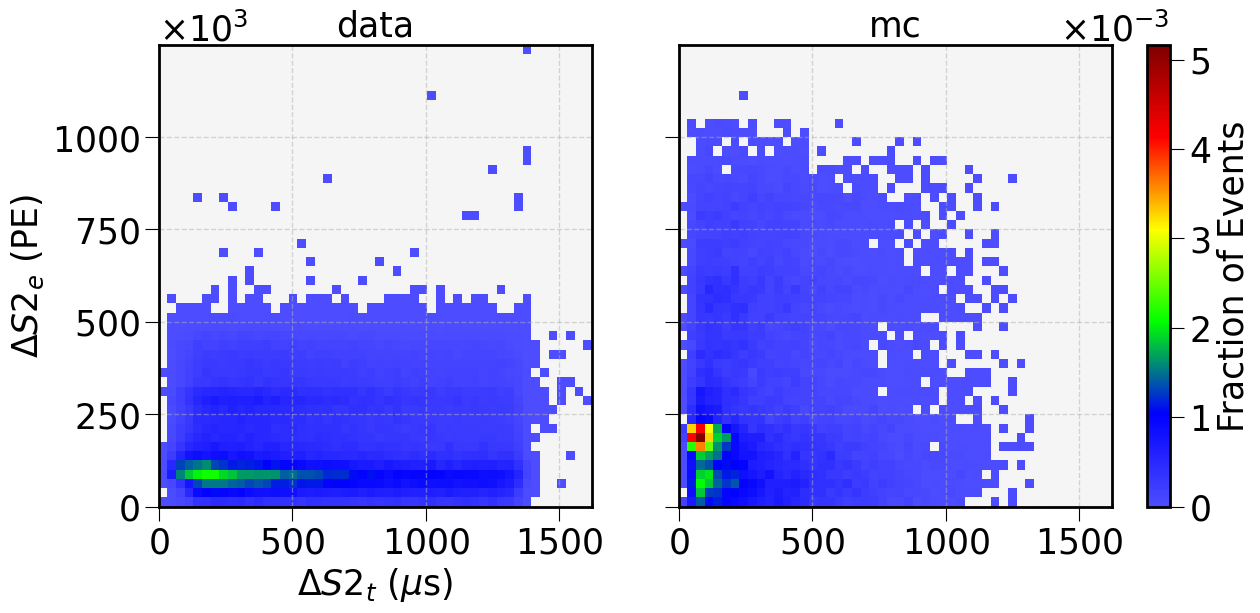

In [118]:
n_bins = 50
diffs = {}
fracs = {}

for ana_type in ANA_INFO.keys():
    dataframe = ANA_INFO[ana_type]['df_reco']
    df_temp = dataframe[dataframe['nS2'] == 2].copy()
    
    # Calculate difference between the two S2 signals for each unique event
    grouped = df_temp.groupby('global_event')
    dS2e = grouped['S2e'].max() - grouped['S2e'].min()          # energy difference in [PE]
    dS2t = (grouped['S2t'].max() - grouped['S2t'].min()) / 1e3  # time difference in [μs]
    
    diffs[ana_type] = {'dS2t': dS2t, 'dS2e': dS2e}

# Determine global minimum and maximum bounds across both datasets
global_t_min = min(diffs['data']['dS2t'].min(), diffs['mc']['dS2t'].min())
global_t_max = max(diffs['data']['dS2t'].max(), diffs['mc']['dS2t'].max())
global_e_min = min(diffs['data']['dS2e'].min(), diffs['mc']['dS2e'].min())
global_e_max = max(diffs['data']['dS2e'].max(), diffs['mc']['dS2e'].max())

# Create a unified bin structure for both plots
t_edges = np.linspace(global_t_min, global_t_max, n_bins + 1)
e_edges = np.linspace(global_e_min, global_e_max, n_bins + 1)

for ana_type in ANA_INFO.keys():
    tot_evts = ANA_INFO[ana_type]['df_reco']['global_event'].nunique()
    dS2t = diffs[ana_type]['dS2t']
    dS2e = diffs[ana_type]['dS2e']
    
    hist_2d, _, _ = np.histogram2d(dS2t, dS2e, bins=[t_edges, e_edges])
    
    # Guardamos la fracción en nuestro diccionario
    fracs[ana_type] = hist_2d / tot_evts

# Encontrados los límites de la escala de color (colorbar compartida)
global_vmax = max(fracs['data'].max(), fracs['mc'].max())
global_vmin = 0  # Un valor mínimo pequeño para la escala, o simplemente 0 si usas lineal

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
im_plot = None

for i, ana_type in enumerate(ANA_INFO.keys()):

    hist_frac = fracs[ana_type]
    hist_frac = np.ma.masked_where(hist_frac == 0, hist_frac)
    
    im_plot = axes[i].pcolormesh(t_edges, e_edges, hist_frac.T, 
                            cmap=crudo.pt.custom_hsv, shading='auto', vmin=global_vmin, vmax=global_vmax)
    axes[0].set_xlabel(r'$\Delta S2_{t}$ ($\mu$s)')
    # axes[i].set_xlim(global_t_min, 1.6e6)
    axes[0].set_ylabel(r'$\Delta S2_{e}$ (PE)')
    # axes[i].set_ylim(global_e_min, 1.5e6)
    axes[i].ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
    axes[i].set_title(f'{ana_type}', fontsize=25, loc='center')
    axes[i].set_facecolor("whitesmoke")
    axes[i].grid(True)

cbar = fig.colorbar(
    im_plot, 
    ax=axes.ravel().tolist(), 
    label='Fraction of Events', 
    shrink=1.0, 
    pad=0.03
)
# cbar.ax.tick_params(labelsize=15)

# plt.tight_layout()
plt.show()